# RSNA Pneumonia — quick look

Sample images and class distribution for the RSNA Pneumonia Detection Challenge
(MD.ai export, adjudicated annotations).

**Classes** come from the `Calculated` label group in the annotation JSON — these are the
final adjudicated labels used for the Kaggle challenge:

| class | meaning |
|---|---|
| `Lung Opacity` | **positive** — pneumonia, comes with bounding boxes |
| `No Lung Opacity / Not Normal` | negative — abnormal chest, but not pneumonia |
| `Normal` | negative — healthy chest |

In [1]:
import json
import os
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pydicom

DATA_ROOT = os.environ.get("THESIS_DATA", "/work3/s251710/thesis_data")
IMG_DIR = os.path.join(DATA_ROOT, "mdai_rsna_project_x9N20BZa_images_2018-07-20-153330")
ANN_JSON = os.path.join(DATA_ROOT, "pneumonia-challenge-annotations-adjudicated-kaggle_2018.json")

## 1. Build a per-study label table

In [2]:
with open(ANN_JSON) as f:
    proj = json.load(f)

# labelId -> (group, name)
label_info = {
    lab["id"]: (grp["name"], lab["name"])
    for grp in proj["labelGroups"]
    for lab in grp["labels"]
}

annotations = proj["datasets"][0]["annotations"]
CLASSES = ["Lung Opacity", "No Lung Opacity / Not Normal", "Normal"]

rows = {}
boxes = defaultdict(list)  # StudyUID -> list of (x, y, w, h)

for a in annotations:
    group, name = label_info[a["labelId"]]
    if group != "Calculated" or name not in CLASSES:
        continue
    uid = a["StudyInstanceUID"]
    rows[uid] = {
        "StudyInstanceUID": uid,
        "SeriesInstanceUID": a["SeriesInstanceUID"],
        "SOPInstanceUID": a["SOPInstanceUID"],
        "label": name,
        "target": int(name == "Lung Opacity"),
    }
    if name == "Lung Opacity" and a.get("data"):
        d = a["data"]
        boxes[uid].append((d["x"], d["y"], d["width"], d["height"]))

df = pd.DataFrame(rows.values())
print(f"{len(df):,} studies")
df.head()

29,684 studies


,StudyInstanceUID,SeriesInstanceUID,SOPInstanceUID,label,target
0,1.2.276.0.7230010.3.1.2.8323329.20779.15178744...,1.2.276.0.7230010.3.1.3.8323329.20779.15178744...,1.2.276.0.7230010.3.1.4.8323329.20779.15178744...,No Lung Opacity / Not Normal,0
1,1.2.276.0.7230010.3.1.2.8323329.19863.15178744...,1.2.276.0.7230010.3.1.3.8323329.19863.15178744...,1.2.276.0.7230010.3.1.4.8323329.19863.15178744...,No Lung Opacity / Not Normal,0
2,1.2.276.0.7230010.3.1.2.8323329.12963.15178743...,1.2.276.0.7230010.3.1.3.8323329.12963.15178743...,1.2.276.0.7230010.3.1.4.8323329.12963.15178743...,No Lung Opacity / Not Normal,0
3,1.2.276.0.7230010.3.1.2.8323329.29425.15178744...,1.2.276.0.7230010.3.1.3.8323329.29425.15178744...,1.2.276.0.7230010.3.1.4.8323329.29425.15178744...,No Lung Opacity / Not Normal,0
4,1.2.276.0.7230010.3.1.2.8323329.13765.15178743...,1.2.276.0.7230010.3.1.3.8323329.13765.15178743...,1.2.276.0.7230010.3.1.4.8323329.13765.15178743...,No Lung Opacity / Not Normal,0


In [3]:
def dicom_path(row):
    """MD.ai export lays images out as StudyUID/SeriesUID/SOPUID.dcm"""
    return os.path.join(
        IMG_DIR,
        row["StudyInstanceUID"],
        row["SeriesInstanceUID"],
        row["SOPInstanceUID"] + ".dcm",
    )


df["path"] = df.apply(dicom_path, axis=1)
print("paths that exist:", df["path"].map(os.path.exists).sum(), "/", len(df))

paths that exist: 29684 / 29684


## 2. Class distribution

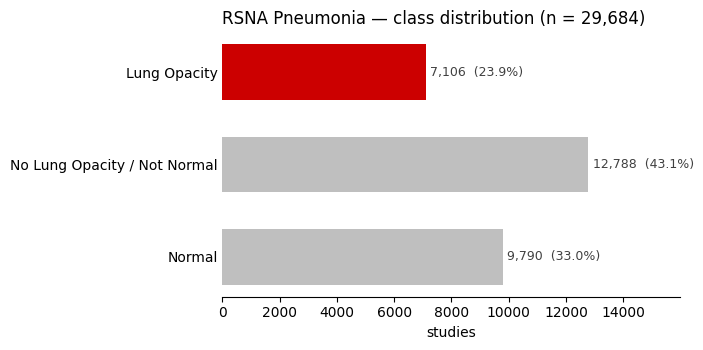

positive (Lung Opacity): 7,106  (23.9%)
negative:                22,578  (76.1%)


In [4]:
counts = df["label"].value_counts().reindex(CLASSES)

fig, ax = plt.subplots(figsize=(7, 3.6))
colors = ["#CC0000", "#BFBFBF", "#BFBFBF"]  # positive highlighted, negatives muted
bars = ax.barh(range(len(counts))[::-1], counts.values, color=colors, height=0.6)

for bar, n in zip(bars, counts.values):
    ax.text(
        bar.get_width() + 150,
        bar.get_y() + bar.get_height() / 2,
        f"{n:,}  ({n / len(df):.1%})",
        va="center",
        fontsize=9,
        color="#404040",
    )

ax.set_yticks(range(len(counts))[::-1])
ax.set_yticklabels(counts.index)
ax.set_xlabel("studies")
ax.set_xlim(0, counts.max() * 1.25)
ax.set_title(f"RSNA Pneumonia — class distribution (n = {len(df):,})", loc="left")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)
plt.tight_layout()
plt.show()

print(f"positive (Lung Opacity): {df.target.sum():,}  ({df.target.mean():.1%})")
print(f"negative:                {(1 - df.target).sum():,}  ({1 - df.target.mean():.1%})")

## 3. Sample images

Top row: positives (pneumonia), with the adjudicated boxes drawn in.
Bottom row: negatives.

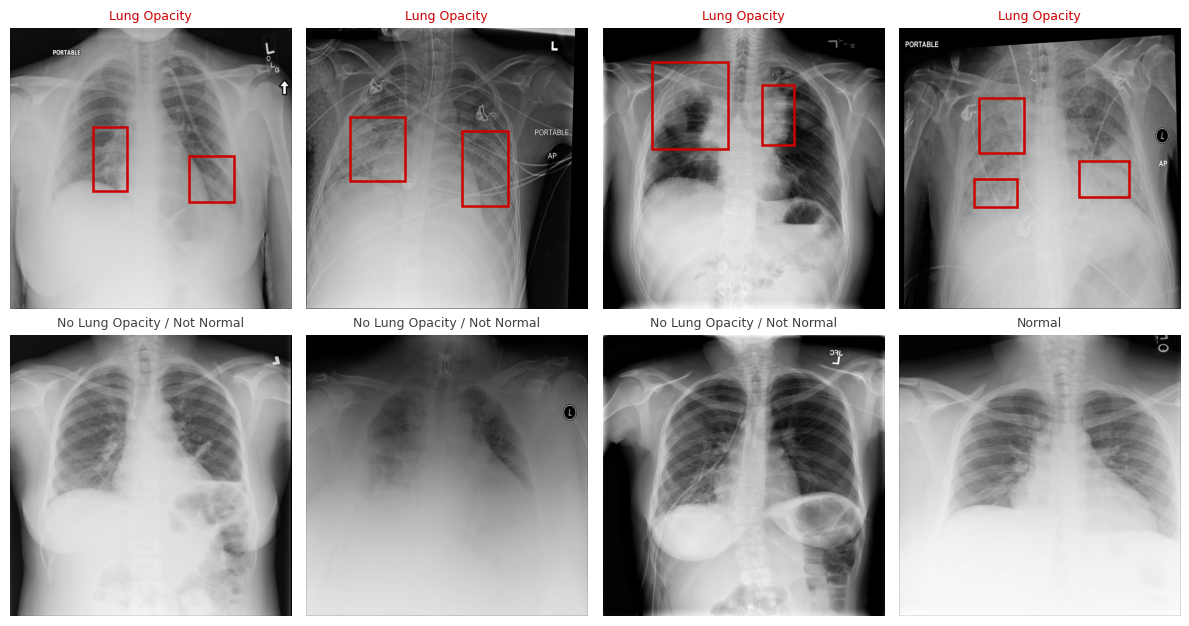

In [5]:
N = 4
rng = np.random.default_rng(0)

pos = df[df.target == 1].sample(N, random_state=0)
neg = df[df.target == 0].sample(N, random_state=0)

fig, axes = plt.subplots(2, N, figsize=(3 * N, 6.4))

for axrow, subset, show_boxes in [(axes[0], pos, True), (axes[1], neg, False)]:
    for ax, (_, row) in zip(axrow, subset.iterrows()):
        img = pydicom.dcmread(row["path"]).pixel_array
        ax.imshow(img, cmap="gray")

        if show_boxes:
            for x, y, w, h in boxes[row["StudyInstanceUID"]]:
                ax.add_patch(
                    plt.Rectangle((x, y), w, h, fill=False, edgecolor="#CC0000", lw=1.8)
                )

        ax.set_title(row["label"], fontsize=9, color="#CC0000" if row.target else "#404040")
        ax.axis("off")

plt.tight_layout()
plt.show()